# Regression

### Imports and config

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import f_oneway
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

KORS_PATH    = Path('../data/original/Forts_IRAF_SAT_Kors _Gemensamt.xlsx')
RAK_PATH     = Path('../data/original/Final_IRAF_SAT_Rak_Bedömare sep och gemensamt.xlsx')
FEATURES_DIR = Path('../data/processed/features')
SELECTED_DIR = FEATURES_DIR / 'combined/per_video'
OUT_DIR      = Path('../data/processed/regression')
OUT_DIR.mkdir(parents=True, exist_ok=True)

PHASE_MAP = {
    'iraf_utgångsposition':  'selected_features_init.csv',
    'iraf_rörelsestart':     'selected_features_start.csv',
    'iraf_rörelseutförande': 'selected_features_execution.csv',
    'iraf_total':            'selected_features_total.csv',
}

## Load IRAF Scores

* Weighted mean over the aspect scores per phase
* Weighted mean over the phase means for the whole movement

In [3]:
def parse_iraf_per_video(xl, sheet_name, fp_videos=None):
    raw = xl.parse(sheet_name, header=None)
    col0 = raw.iloc[:, 0].fillna('').astype(str)

    # Support header formats:
    #   KORS: "Försöksperson: SB. Film Nr: 028"
    #   RAK sit-to-stand: "Fp1_Sittande till stående, Video 030"
    #   RAK stand-to-sit: "Fp1_Stående till sittande" (no video; pass fp_videos)
    is_block = col0.str.contains('Film Nr', na=False) | col0.str.contains(', [Vv]ideo ', na=False, regex=True)
    if fp_videos is not None:
        is_block = is_block | col0.str.match(r'Fp\d+_', na=False)
    block_rows = raw.index[is_block].tolist()
    block_rows.append(len(raw))

    def get_video(text):
        if 'Film Nr' in text:
            return text.split('Film Nr:')[1].strip().split()[0].zfill(4)
        elif ', video ' in text.lower():
            return text.lower().split(', video ')[1].strip().split()[0].zfill(4)
        elif fp_videos is not None:
            m = re.match(r'Fp(\d+)_', text)
            if m:
                idx = int(m.group(1)) - 1
                return fp_videos[idx] if idx < len(fp_videos) else None
        return None

    records = []
    phase_weight_records = []
    for i, start in enumerate(block_rows[:-1]):
        video = get_video(col0.iloc[start])
        if video is None:
            continue
        block = raw.iloc[start:block_rows[i+1]]
        bc0 = block.iloc[:, 0].fillna('').astype(str)
        up_idx = bc0[bc0.str.strip() == 'Utgångsposition'].index
        rs_idx = bc0[bc0.str.strip() == 'Rörelsestart'].index
        ru_idx = bc0[bc0.str.strip() == 'Rörelseutförande'].index
        if not (len(up_idx) and len(rs_idx) and len(ru_idx)):
            continue
        up_i, rs_i, ru_i = up_idx[0], rs_idx[0], ru_idx[0]
        end_i = block_rows[i+1]
        for phase, p_i in [('utgångsposition', up_i), ('rörelsestart', rs_i), ('rörelseutförande', ru_i)]:
            phase_weight_records.append({'video': video, 'phase': phase, 'phase_weight': raw.iloc[p_i, 1]})
        for phase, p_start, p_end in [
            ('utgångsposition', up_i+1, rs_i),
            ('rörelsestart',    rs_i+1, ru_i),
            ('rörelseutförande', ru_i+1, end_i)
        ]:
            for _, r in raw.iloc[p_start:p_end].iterrows():
                gem = r[12]
                weight = pd.to_numeric(r[1], errors='coerce')
                if pd.notna(weight) and pd.notna(gem) and str(gem).strip().lower() != 'x':
                    records.append({'video': video, 'phase': phase,
                                    'weight': weight, 'avvikelse': float(gem)})
    return pd.DataFrame(records), pd.DataFrame(phase_weight_records)

kors_xl = pd.ExcelFile(KORS_PATH)
rak_xl  = pd.ExcelFile(RAK_PATH)
kors_df, kors_pw = parse_iraf_per_video(kors_xl, 'Sittande till stående')
rak_df,  rak_pw  = parse_iraf_per_video(rak_xl,  'Sittande till stående')
iraf_raw = pd.concat([kors_df, rak_df], ignore_index=True)
iraf_raw = iraf_raw.assign(w=iraf_raw['avvikelse'] * iraf_raw['weight'])

phase_weights = pd.concat([kors_pw, rak_pw]).groupby('phase')['phase_weight'].mean().to_dict()

iraf_pv = iraf_raw.groupby(['video', 'phase']).apply(
    lambda g: g['w'].sum() / g['weight'].sum()
).unstack().reset_index()
iraf_pv.columns.name = None
iraf_pv.columns = ['video'] + [f'iraf_{c}' for c in iraf_pv.columns[1:]]

total_w = sum(phase_weights.values())
iraf_pv['iraf_total'] = sum(iraf_pv[f'iraf_{p}'] * w for p, w in phase_weights.items()) / total_w

iraf_pv

,video,iraf_rörelsestart,iraf_rörelseutförande,iraf_utgångsposition,iraf_total
0,0028,1.666667,0.791667,0.870370,1.149306
1,0030,0.000000,0.250000,0.055556,0.083333
2,0045,1.333333,1.208333,1.407407,1.329861
3,0047,2.000000,0.812500,1.523810,1.524554
4,0059,1.000000,0.812500,0.937500,0.929688
5,0061,1.000000,0.687500,0.650000,0.790625
6,0074,1.666667,1.041667,1.047619,1.278274
7,0076,1.000000,0.937500,0.555556,0.817708
8,0091,1.666667,1.023810,1.460317,1.428571
9,0093,1.000000,0.500000,0.722222,0.770833


## Load top correlated features per phase

In [4]:
pose_all = (
    pd.read_csv(FEATURES_DIR / 'utgångsposition.csv')
    .merge(pd.read_csv(FEATURES_DIR / 'rörelsestart.csv'),     on='video')
    .merge(pd.read_csv(FEATURES_DIR / 'rörelseutförande.csv'), on='video')
)
molab_all = (
    pd.read_csv(FEATURES_DIR / 'molab_utgångsposition.csv')
    .merge(pd.read_csv(FEATURES_DIR / 'molab_rörelsestart.csv'),     on='video')
    .merge(pd.read_csv(FEATURES_DIR / 'molab_rörelseutförande.csv'), on='video')
)

pose_all['video']  = pose_all['video'].astype(str).str.zfill(3)
molab_all['video'] = molab_all['video'].astype(str).str.zfill(3)
pose_all  = pose_all.rename(columns={c: f'pose_{c}'  for c in pose_all.columns  if c != 'video'})
molab_all = molab_all.rename(columns={c: f'molab_{c}' for c in molab_all.columns if c != 'video'})

iraf = iraf_pv.copy()
iraf['video'] = iraf['video'].astype(str).str[-3:]

phase_dfs = {}
for target, fname in PHASE_MAP.items():
    sel = pd.read_csv(SELECTED_DIR / fname)
    pose_feats  = [f'pose_{f}'  for f in sel[sel['source'] == 'Pose']['feature'].tolist()]
    molab_feats = [f'molab_{f}' for f in sel[sel['source'] == 'MoLab']['feature'].tolist()]
    short = target.replace('iraf_', '')
    pose_df  = pose_all[['video'] + pose_feats]
    molab_df = molab_all[['video'] + molab_feats]
    phase_dfs[short] = {
        'pose':     pose_df,
        'molab':    molab_df,
        'combined': pose_df.merge(molab_df, on='video'),
        'y':        iraf[['video', target]],
    }

for phase, sources in phase_dfs.items():
    print(f"\n{phase}:")
    for source, val in sources.items():
        if source == 'y':
            scores = val.iloc[:, 1].round(2).tolist()
            print(f"  y: {scores}")
        else:
            print(f"  {source}: {val.shape} {val.columns[1:].tolist()}")


utgångsposition:
  pose: (10, 4) ['pose_forb_trunk_hip_correlation', 'pose_initial_trunk_angle', 'pose_mean_left_hip_angle']
  molab: (10, 6) ['molab_mean_R_knee_flexion', 'molab_delta_pelvis_tilt', 'molab_peak_pelvis_gyro', 'molab_forb_peak_pelvis_gyro', 'molab_uppr_total_knee_extension']
  combined: (10, 9) ['pose_forb_trunk_hip_correlation', 'pose_initial_trunk_angle', 'pose_mean_left_hip_angle', 'molab_mean_R_knee_flexion', 'molab_delta_pelvis_tilt', 'molab_peak_pelvis_gyro', 'molab_forb_peak_pelvis_gyro', 'molab_uppr_total_knee_extension']
  y: [0.87, 0.06, 1.41, 1.52, 0.94, 0.65, 1.05, 0.56, 1.46, 0.72]

rörelsestart:
  pose: (10, 4) ['pose_forb_trunk_hip_correlation', 'pose_rms_angular_acceleration', 'pose_delta_trunk_flexion']
  molab: (10, 4) ['molab_mean_pelvis_lateral', 'molab_forb_peak_pelvis_gyro', 'molab_peak_pelvis_gyro']
  combined: (10, 7) ['pose_forb_trunk_hip_correlation', 'pose_rms_angular_acceleration', 'pose_delta_trunk_flexion', 'molab_mean_pelvis_lateral', 'mol

## Regression: LOOCV

In [5]:
MODELS = {
    'Linear':       LinearRegression(),
    'Ridge':        Ridge(),
    'RandomForest': RandomForestRegressor(max_depth=3, n_estimators=50, random_state=42),
}

FEATURE_SETS = ['pose', 'molab', 'combined']
MODEL_ORDER  = ['Linear', 'Ridge', 'RandomForest']

loo = LeaveOneOut()
loocv_results = []

for phase, data in phase_dfs.items():
    y = data['y'].iloc[:, 1].values
    for fs in FEATURE_SETS:
        X = data[fs].drop(columns='video').values
        feature_names = data[fs].drop(columns='video').columns.tolist()
        for model_name, model in MODELS.items():
            preds = np.empty(len(y))
            importances = []
            for train_idx, test_idx in loo.split(X):
                scaler = StandardScaler()
                X_train = scaler.fit_transform(X[train_idx])
                X_test  = scaler.transform(X[test_idx])
                m = clone(model)
                m.fit(X_train, y[train_idx])
                preds[test_idx] = m.predict(X_test)
                if model_name == 'RandomForest':
                    importances.append(m.feature_importances_)
            entry = {
                'phase':       phase,
                'feature_set': fs,
                'model':       model_name,
                'y_true':      y.copy(),
                'y_pred':      preds,
            }
            if model_name == 'RandomForest':
                entry['feature_names']        = feature_names
                entry['mean_importances'] = np.mean(importances, axis=0)
            loocv_results.append(entry)

print(f"{len(loocv_results)} models trained ({len(phase_dfs)} phases x {len(FEATURE_SETS)} feature sets x {len(MODELS)} models)")

36 models trained (4 phases x 3 feature sets x 3 models)


## Evaluation

In [6]:
rows = []
for r in loocv_results:
    mae  = mean_absolute_error(r['y_true'], r['y_pred'])
    rmse = np.sqrt(mean_squared_error(r['y_true'], r['y_pred']))
    r2   = r2_score(r['y_true'], r['y_pred'])
    rows.append({
        'phase':       r['phase'],
        'model':       r['model'],
        'feature_set': r['feature_set'],
        'MAE':         mae,
        'RMSE':        rmse,
        'R2':          r2,
    })

eval_df = pd.DataFrame(rows)

for phase in eval_df['phase'].unique():
    print(f"\n{'='*60}")
    print(f"Phase: {phase}")
    print(f"{'='*60}")
    for metric in ['MAE', 'RMSE', 'R2']:
        pivot = eval_df[eval_df['phase'] == phase].pivot(
            index='model', columns='feature_set', values=metric
        ).loc[MODEL_ORDER, ['pose', 'molab', 'combined']]
        print(f"\n{metric}:")
        print(pivot.round(3).to_string())


Phase: utgångsposition

MAE:
feature_set    pose  molab  combined
model                               
Linear        0.308  0.504     2.453
Ridge         0.289  0.268     0.349
RandomForest  0.311  0.294     0.305

RMSE:
feature_set    pose  molab  combined
model                               
Linear        0.376  0.601     4.157
Ridge         0.366  0.344     0.421
RandomForest  0.419  0.390     0.380

R2:
feature_set    pose  molab  combined
model                               
Linear        0.260 -0.899   -89.710
Ridge         0.298  0.380     0.068
RandomForest  0.080  0.202     0.242

Phase: rörelsestart

MAE:
feature_set    pose  molab  combined
model                               
Linear        0.606  0.743     0.747
Ridge         0.539  0.414     0.643
RandomForest  0.398  0.354     0.392

RMSE:
feature_set    pose  molab  combined
model                               
Linear        0.842  1.052     0.927
Ridge         0.756  0.568     0.797
RandomForest  0.612  0.554     0.597

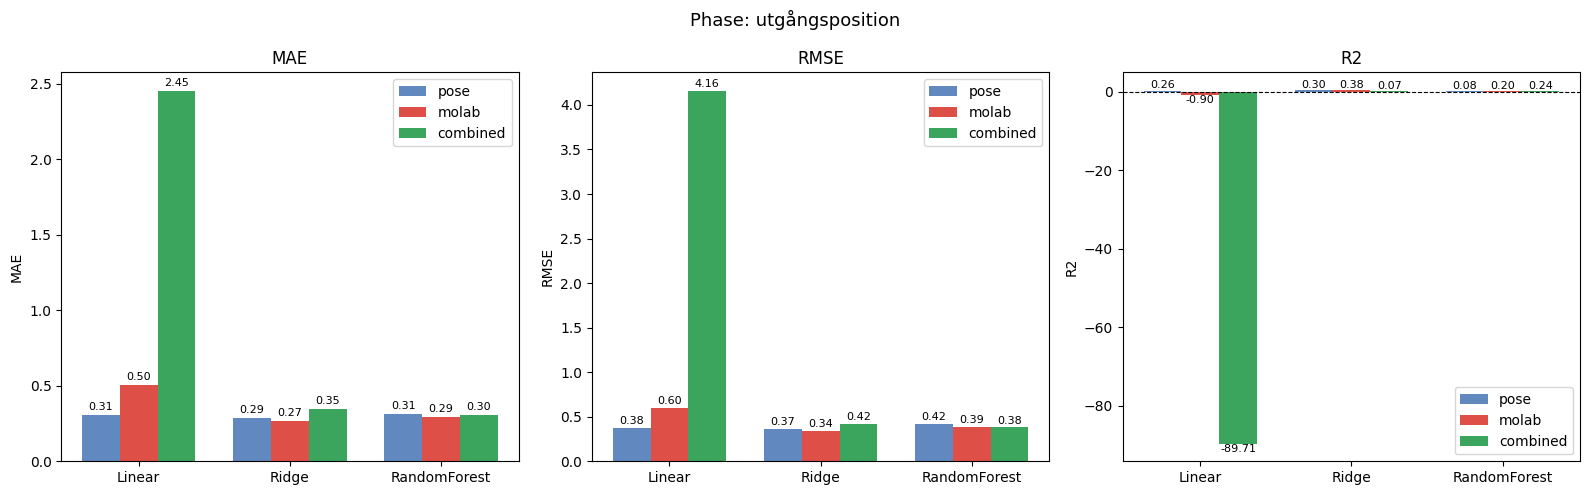

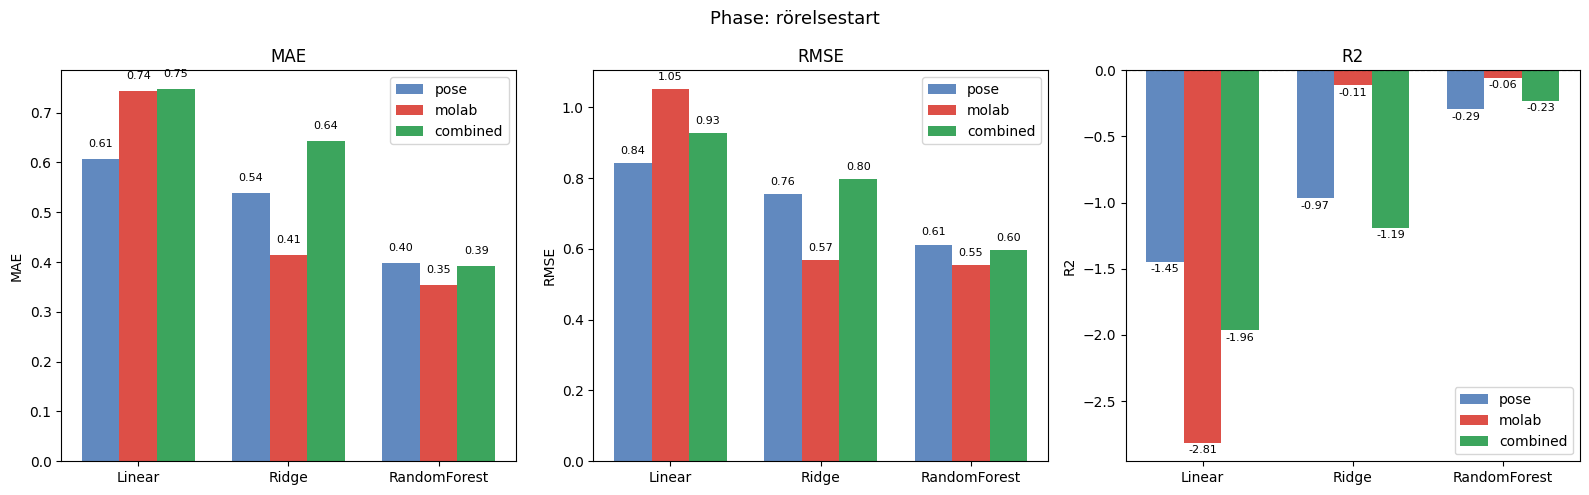

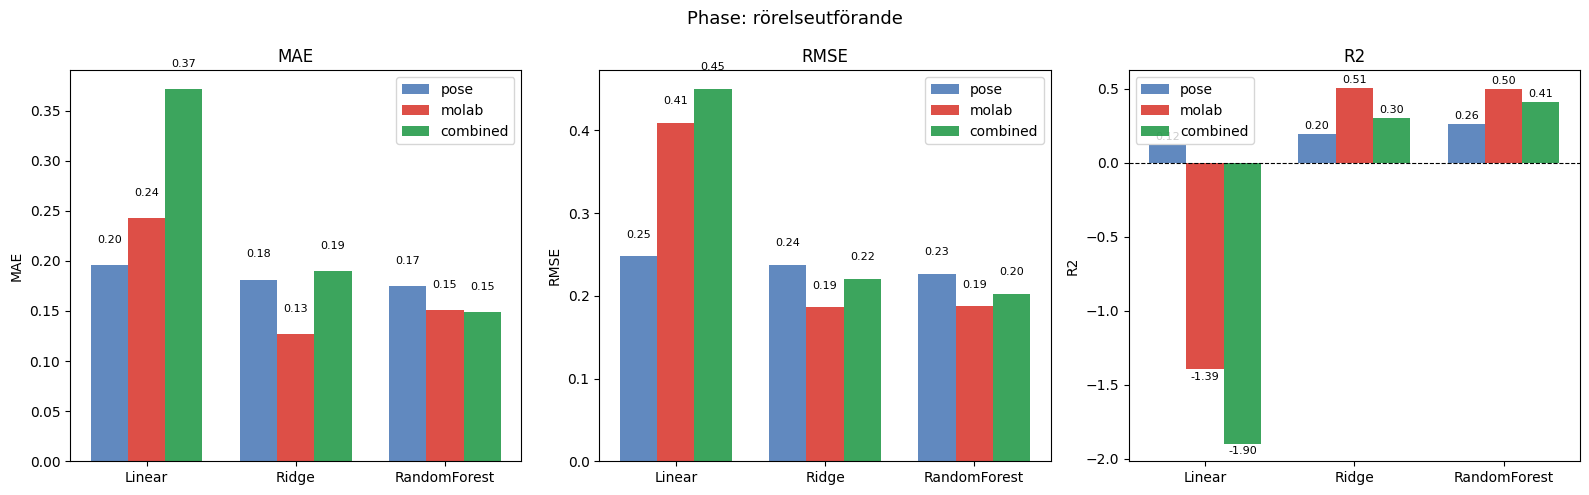

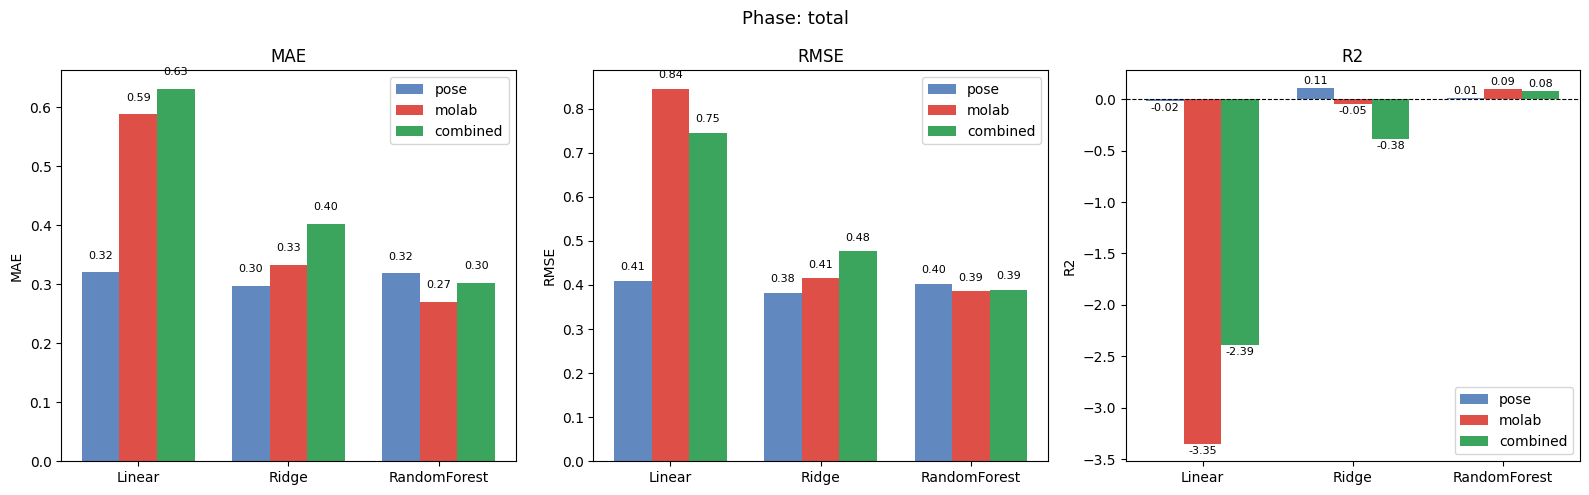

In [7]:
METRICS      = ['MAE', 'RMSE', 'R2']
COLORS       = {'pose': '#4575b4', 'molab': '#d73027', 'combined': '#1a9641'}

x = np.arange(len(MODEL_ORDER))
width = 0.25

for phase in eval_df['phase'].unique():
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Phase: {phase}', fontsize=13)

    for ax, metric in zip(axes, METRICS):
        sub = eval_df[eval_df['phase'] == phase]
        for i, fs in enumerate(FEATURE_SETS):
            vals = [sub[(sub['model'] == m) & (sub['feature_set'] == fs)][metric].values[0]
                    for m in MODEL_ORDER]
            bars = ax.bar(x + i * width, vals, width, label=fs, color=COLORS[fs], alpha=0.85)
            for bar, val in zip(bars, vals):
                y_pos = bar.get_height() + (0.02 if val >= 0 else -0.02)
                va = 'bottom' if val >= 0 else 'top'
                ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
                        f'{val:.2f}', ha='center', va=va, fontsize=8)

        ax.set_title(metric)
        ax.set_xticks(x + width)
        ax.set_xticklabels(MODEL_ORDER)
        ax.set_ylabel(metric)
        if metric == 'R2':
            ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.legend()

    plt.tight_layout()
    plt.savefig(OUT_DIR / f'regression_{phase}.png', dpi=150, bbox_inches='tight')
    plt.show()

## ANOVA: prediction errors across feature sets

In [8]:
anova_rows = []

for phase in eval_df['phase'].unique():
    for model in MODEL_ORDER:
        errors = {}
        for fs in FEATURE_SETS:
            r = next(x for x in loocv_results
                     if x['phase'] == phase and x['model'] == model and x['feature_set'] == fs)
            errors[fs] = np.abs(r['y_true'] - r['y_pred'])

        f_stat, p_val = f_oneway(errors['pose'], errors['molab'], errors['combined'])
        anova_rows.append({
            'phase': phase, 'model': model,
            'F': round(f_stat, 3), 'p': round(p_val, 3),
            'significant': p_val < 0.05,
        })

anova_df = pd.DataFrame(anova_rows)
anova_df

,phase,model,F,p,significant
0,utgångsposition,Linear,3.328,0.051,False
1,utgångsposition,Ridge,0.310,0.736,False
2,utgångsposition,RandomForest,0.010,0.990,False
3,rörelsestart,Linear,0.146,0.865,False
4,rörelsestart,Ridge,0.544,0.587,False
5,rörelsestart,RandomForest,0.025,0.975,False
6,rörelseutförande,Linear,1.145,0.333,False
7,rörelseutförande,Ridge,0.572,0.571,False
8,rörelseutförande,RandomForest,0.107,0.899,False
9,total,Linear,1.301,0.289,False


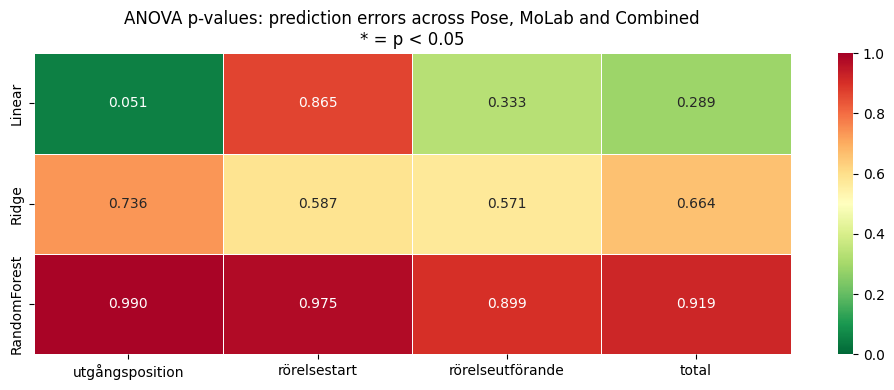

In [9]:
PHASE_ORDER = ['utgångsposition', 'rörelsestart', 'rörelseutförande', 'total']

pivot_p = anova_df.pivot(index='model', columns='phase', values='p')
pivot_p = pivot_p.loc[MODEL_ORDER, PHASE_ORDER]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_p, annot=True, fmt='.3f', cmap='RdYlGn_r', vmin=0, vmax=1,
            ax=ax, linewidths=0.5, annot_kws={'size': 10})
for i, model in enumerate(pivot_p.index):
    for j, phase in enumerate(pivot_p.columns):
        if pivot_p.loc[model, phase] < 0.05:
            ax.text(j + 0.5, i + 0.75, '*', ha='center', va='center', fontsize=14, fontweight='bold')

ax.set_title('ANOVA p-values: prediction errors across Pose, MoLab and Combined\n* = p < 0.05', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUT_DIR / 'anova_pvalues.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance (Random Forest)

In [10]:
for phase in PHASE_ORDER:
    print(f"\n{'='*60}")
    print(f"Phase: {phase}")
    print(f"{'='*60}")
    for fs in FEATURE_SETS:
        r = next(x for x in loocv_results
                 if x['phase'] == phase and x['model'] == 'RandomForest' and x['feature_set'] == fs)
        df = pd.DataFrame({
            'feature':    r['feature_names'],
            'importance': r['mean_importances'],
        }).sort_values('importance', ascending=False).reset_index(drop=True)
        print(f"\n{fs}:")
        print(df.round(4).to_string(index=False))


Phase: utgångsposition

pose:
                        feature  importance
pose_forb_trunk_hip_correlation      0.3941
       pose_mean_left_hip_angle      0.3261
       pose_initial_trunk_angle      0.2797

molab:
                        feature  importance
molab_uppr_total_knee_extension      0.3195
      molab_mean_R_knee_flexion      0.2359
         molab_peak_pelvis_gyro      0.1878
        molab_delta_pelvis_tilt      0.1728
    molab_forb_peak_pelvis_gyro      0.0841

combined:
                        feature  importance
      molab_mean_R_knee_flexion      0.2107
molab_uppr_total_knee_extension      0.2024
pose_forb_trunk_hip_correlation      0.1382
       pose_mean_left_hip_angle      0.1182
         molab_peak_pelvis_gyro      0.1032
        molab_delta_pelvis_tilt      0.0817
    molab_forb_peak_pelvis_gyro      0.0743
       pose_initial_trunk_angle      0.0713

Phase: rörelsestart

pose:
                        feature  importance
       pose_delta_trunk_flexion      0.421

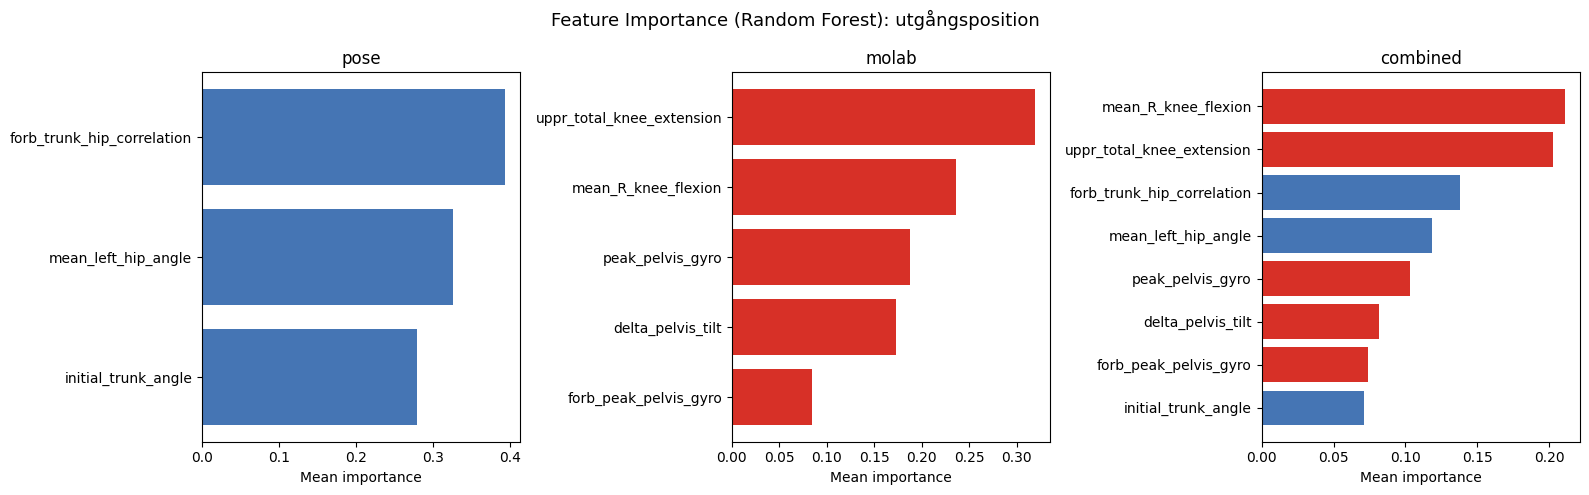

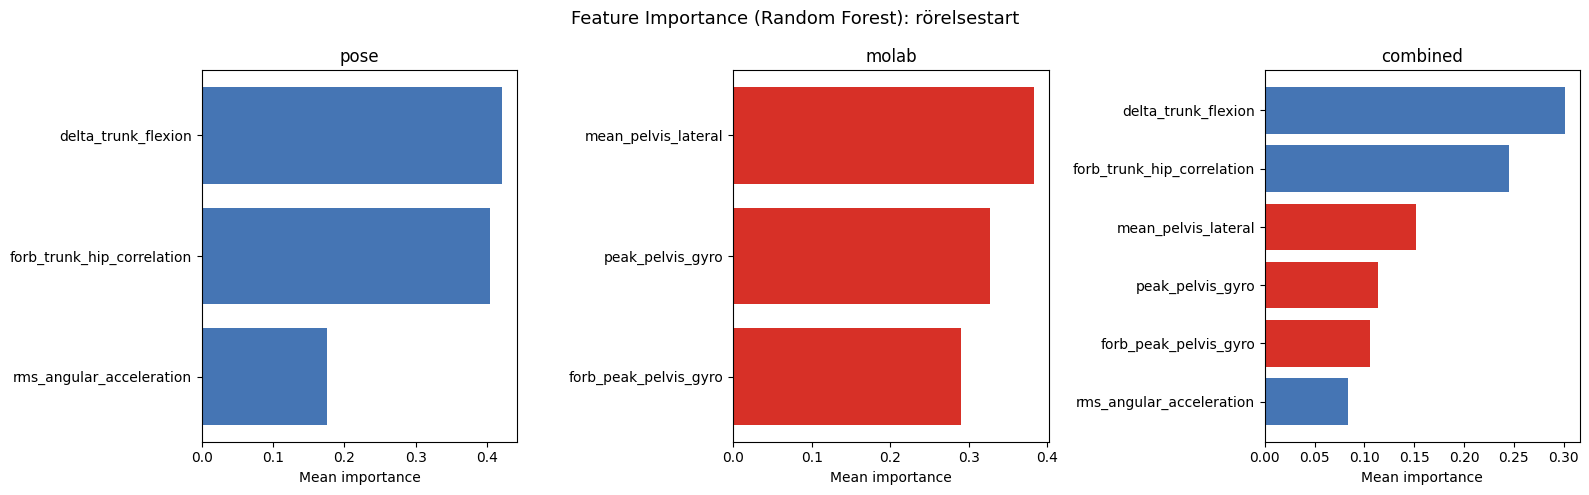

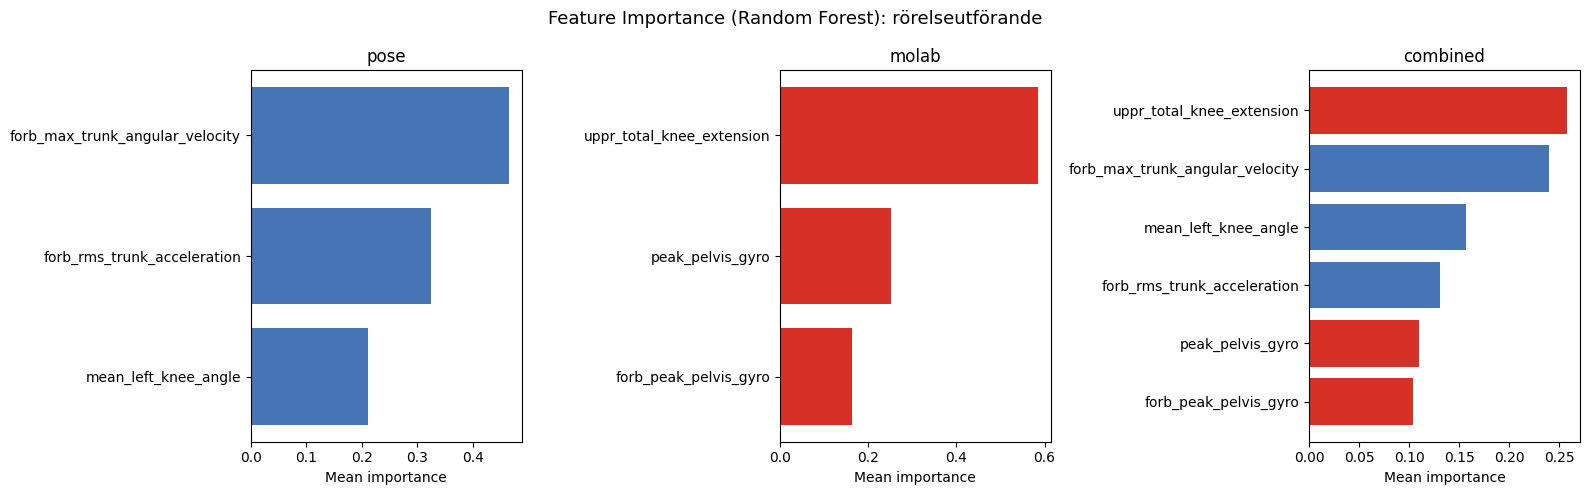

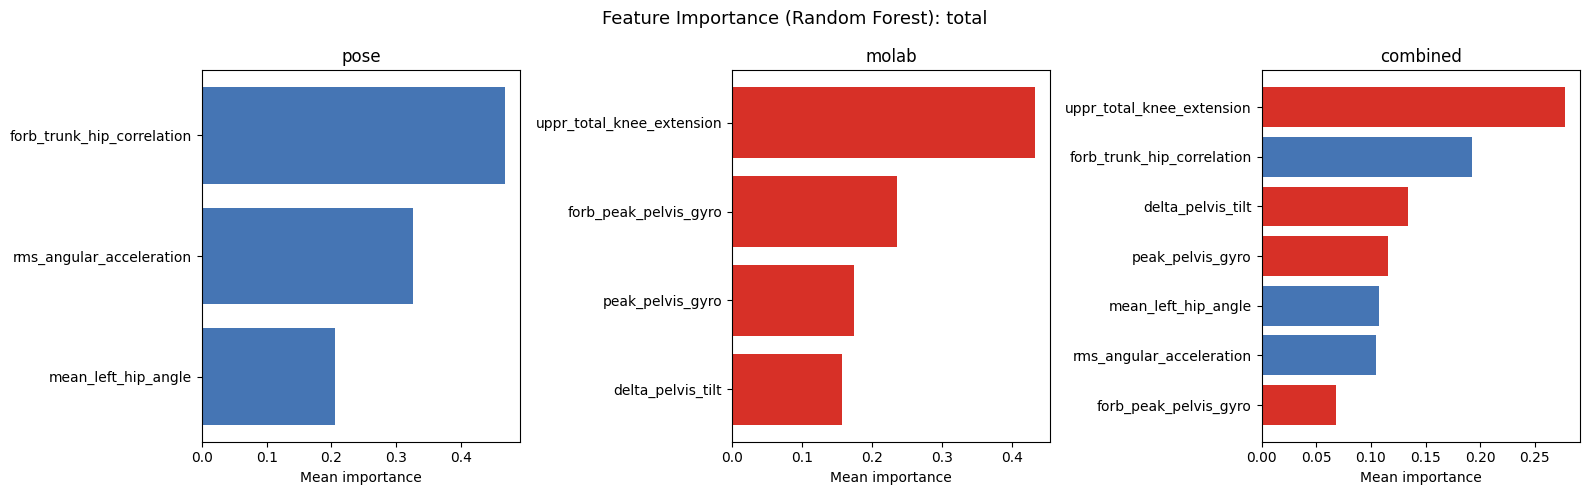

In [11]:
PHASE_ORDER = ['utgångsposition', 'rörelsestart', 'rörelseutförande', 'total']

for phase in PHASE_ORDER:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Feature Importance (Random Forest): {phase}', fontsize=13)

    for ax, fs in zip(axes, FEATURE_SETS):
        r = next(x for x in loocv_results
                 if x['phase'] == phase and x['model'] == 'RandomForest' and x['feature_set'] == fs)
        names = [n.replace('pose_', '').replace('molab_', '') for n in r['feature_names']]
        imps  = r['mean_importances']
        order = np.argsort(imps)
        colors = ['#d73027' if 'molab_' in r['feature_names'][i] else '#4575b4' for i in order]
        ax.barh([names[i] for i in order], imps[order], color=colors)
        ax.set_title(fs)
        ax.set_xlabel('Mean importance')

    plt.tight_layout()
    plt.savefig(OUT_DIR / f'feature_importance_{phase}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Error Analysis (Random Forest): Pose vs MoLab per video

In [12]:
videos = phase_dfs['utgångsposition']['y']['video'].tolist()

for phase in PHASE_ORDER:
    pose_r  = next(r for r in loocv_results if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'pose')
    molab_r = next(r for r in loocv_results if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'molab')

    df = pd.DataFrame({
        'video':       videos,
        'pose_error':  np.abs(pose_r['y_true']  - pose_r['y_pred']),
        'molab_error': np.abs(molab_r['y_true'] - molab_r['y_pred']),
    })
    df['better'] = df.apply(lambda row: 'Pose' if row['pose_error'] < row['molab_error'] else 'MoLab', axis=1)

    print(f"\n{'='*60}")
    print(f"Phase: {phase}")
    print(f"{'='*60}")
    print(df.round(4).to_string(index=False))


Phase: utgångsposition
video  pose_error  molab_error better
  028      0.0455       0.1641   Pose
  030      0.6602       0.7756   Pose
  045      0.5027       0.0917  MoLab
  047      0.7866       0.7476  MoLab
  059      0.0399       0.2621   Pose
  061      0.2004       0.3998   Pose
  074      0.0819       0.0169  MoLab
  076      0.0145       0.0626   Pose
  091      0.6029       0.1900  MoLab
  093      0.1773       0.2346   Pose

Phase: rörelsestart
video  pose_error  molab_error better
  028      0.4667       0.0120  MoLab
  030      1.0800       1.1400   Pose
  045      0.1733       0.2200   Pose
  047      1.4467       1.1933  MoLab
  059      0.1278       0.1333   Pose
  061      0.4267       0.3400  MoLab
  074      0.2033       0.3933   Pose
  076      0.0067       0.0333   Pose
  091      0.0322       0.0413   Pose
  093      0.0133       0.0333   Pose

Phase: rörelseutförande
video  pose_error  molab_error better
  028      0.1364       0.2069   Pose
  030      0.5343 

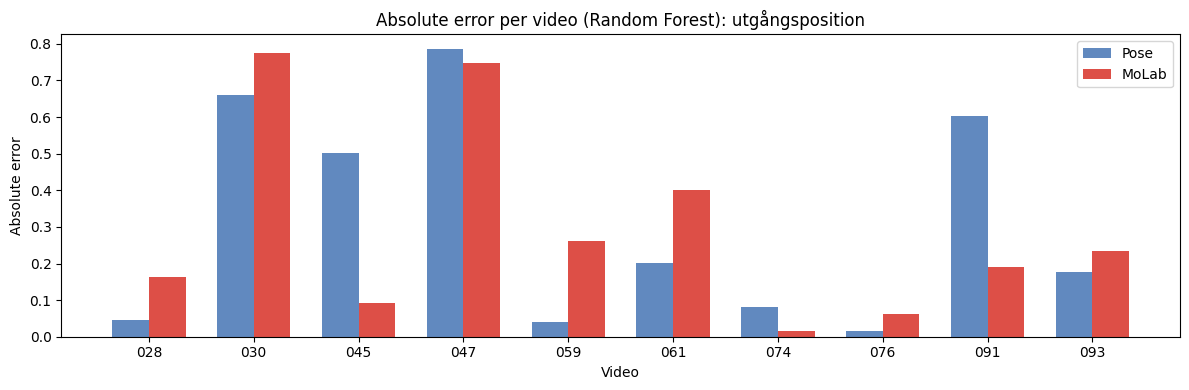

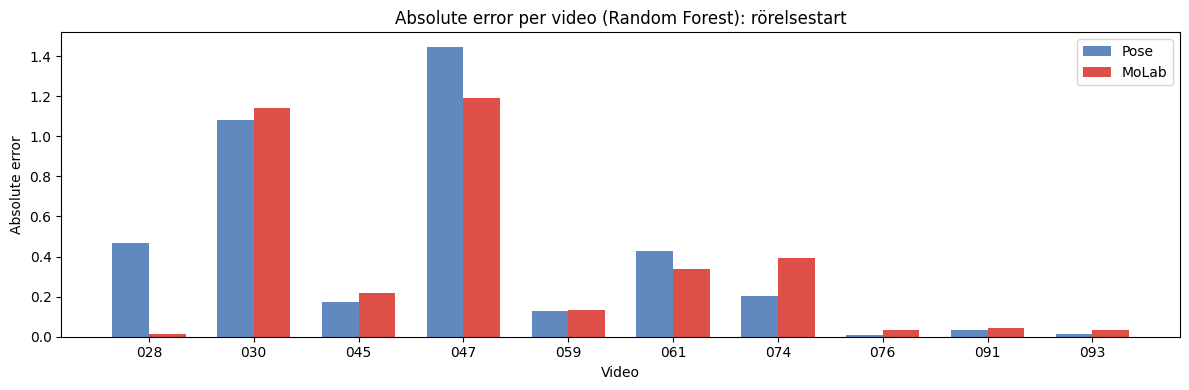

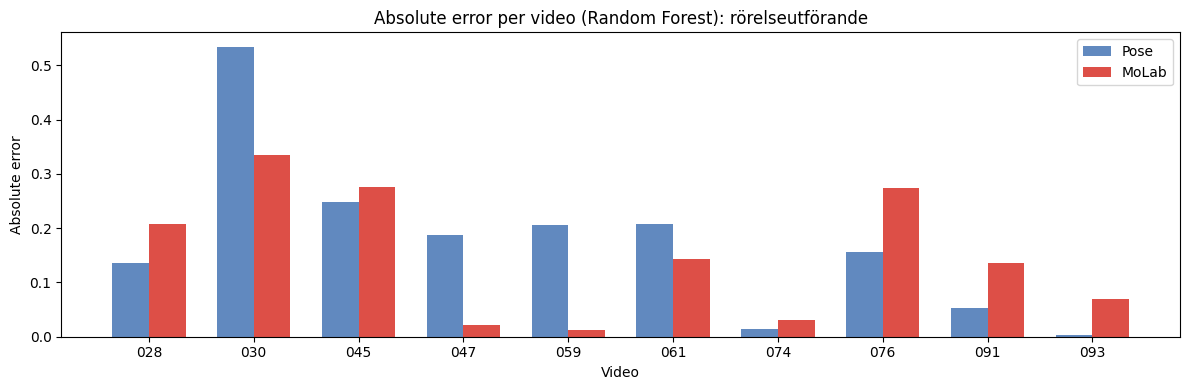

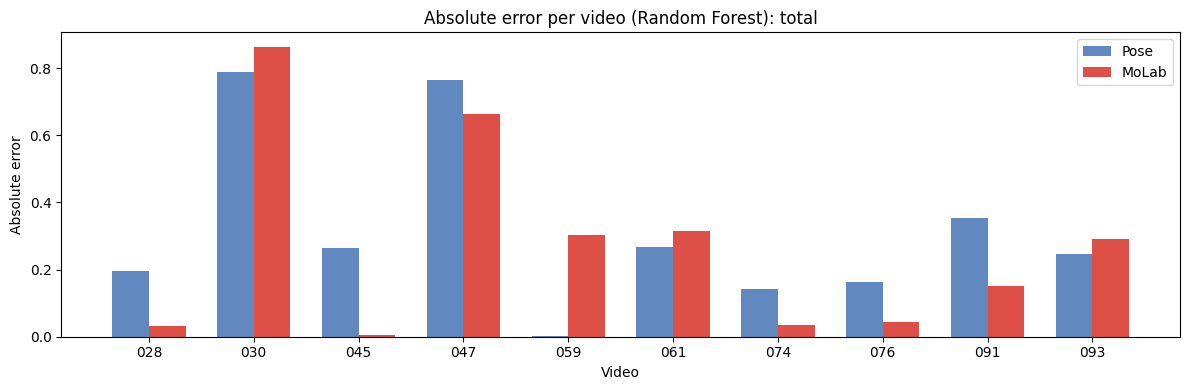

In [13]:
videos = phase_dfs['utgångsposition']['y']['video'].tolist()

x = np.arange(len(videos))
width = 0.35

for phase in PHASE_ORDER:
    pose_r  = next(r for r in loocv_results if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'pose')
    molab_r = next(r for r in loocv_results if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'molab')

    pose_errors  = np.abs(pose_r['y_true']  - pose_r['y_pred'])
    molab_errors = np.abs(molab_r['y_true'] - molab_r['y_pred'])

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(x - width/2, pose_errors,  width, label='Pose',  color='#4575b4', alpha=0.85)
    ax.bar(x + width/2, molab_errors, width, label='MoLab', color='#d73027', alpha=0.85)

    ax.set_title(f'Absolute error per video (Random Forest): {phase}')
    ax.set_xticks(x)
    ax.set_xticklabels(videos)
    ax.set_xlabel('Video')
    ax.set_ylabel('Absolute error')
    ax.legend()

    plt.tight_layout()
    plt.savefig(OUT_DIR / f'error_analysis_{phase}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Stående till sittande (Stand-to-Sit)

In [14]:
OUT_DIR_DOWN = Path('../data/processed/regression_down')
OUT_DIR_DOWN.mkdir(parents=True, exist_ok=True)

DOWN_FEATURES_DIR = Path('../data/processed/features_down')
DOWN_SELECTED_DIR = DOWN_FEATURES_DIR / 'combined/per_video'

PHASE_MAP_DOWN = {
    'iraf_utgångsposition':  'selected_features_init.csv',
    'iraf_rörelsestart':     'selected_features_start.csv',
    'iraf_rörelseutförande': 'selected_features_execution.csv',
    'iraf_total':            'selected_features_total.csv',
}

RAK_DOWN_FP_VIDEOS = ['030', '047', '061', '076', '093']

kors_df_d, kors_pw_d = parse_iraf_per_video(kors_xl, 'Stående till sittande')
rak_df_d,  rak_pw_d  = parse_iraf_per_video(rak_xl,  'Stående till sittande', fp_videos=RAK_DOWN_FP_VIDEOS)
iraf_raw_d = pd.concat([kors_df_d, rak_df_d], ignore_index=True)
iraf_raw_d = iraf_raw_d.assign(w=iraf_raw_d['avvikelse'] * iraf_raw_d['weight'])

phase_weights_d = pd.concat([kors_pw_d, rak_pw_d]).groupby('phase')['phase_weight'].mean().to_dict()

iraf_pv_d = iraf_raw_d.groupby(['video', 'phase']).apply(
    lambda g: g['w'].sum() / g['weight'].sum()
).unstack().reset_index()
iraf_pv_d.columns.name = None
iraf_pv_d.columns = ['video'] + [f'iraf_{c}' for c in iraf_pv_d.columns[1:]]

total_w_d = sum(phase_weights_d.values())
iraf_pv_d['iraf_total'] = sum(iraf_pv_d[f'iraf_{p}'] * w for p, w in phase_weights_d.items()) / total_w_d

iraf_pv_d


,video,iraf_rörelsestart,iraf_rörelseutförande,iraf_utgångsposition,iraf_total
0,0028,0.000000,0.545455,0.428571,0.339518
1,0045,0.333333,0.833333,1.125000,0.815476
2,0059,0.000000,0.564103,0.666667,0.446886
3,0074,0.666667,0.692308,0.444444,0.578755
4,0091,0.333333,0.641026,0.555556,0.516484
5,030,0.000000,0.000000,0.000000,0.000000
6,047,1.000000,0.555556,0.600000,0.701587
7,061,0.000000,0.461538,0.733333,0.446154
8,076,2.000000,0.461538,1.133333,1.189011
9,093,0.000000,0.833333,1.000000,0.666667


In [15]:
pose_all_d = (
    pd.read_csv(DOWN_FEATURES_DIR / 'down_utgångsposition.csv')
    .merge(pd.read_csv(DOWN_FEATURES_DIR / 'down_rörelsestart.csv'),     on='video')
    .merge(pd.read_csv(DOWN_FEATURES_DIR / 'down_rörelseutförande.csv'), on='video')
)
molab_all_d = (
    pd.read_csv(DOWN_FEATURES_DIR / 'down_molab_utgångsposition.csv')
    .merge(pd.read_csv(DOWN_FEATURES_DIR / 'down_molab_rörelsestart.csv'),     on='video')
    .merge(pd.read_csv(DOWN_FEATURES_DIR / 'down_molab_rörelseutförande.csv'), on='video')
)

pose_all_d['video']  = pose_all_d['video'].astype(str).str.zfill(3)
molab_all_d['video'] = molab_all_d['video'].astype(str).str.zfill(3)
pose_all_d  = pose_all_d.rename(columns={c: f'pose_{c}'  for c in pose_all_d.columns  if c != 'video'})
molab_all_d = molab_all_d.rename(columns={c: f'molab_{c}' for c in molab_all_d.columns if c != 'video'})

iraf_d = iraf_pv_d.copy()
iraf_d['video'] = iraf_d['video'].astype(str).str[-3:]

phase_dfs_down = {}
for target, fname in PHASE_MAP_DOWN.items():
    sel = pd.read_csv(DOWN_SELECTED_DIR / fname)
    pose_feats  = [f'pose_{f}'  for f in sel[sel['source'] == 'Pose']['feature'].tolist()]
    molab_feats = [f'molab_{f}' for f in sel[sel['source'] == 'MoLab']['feature'].tolist()]
    short = target.replace('iraf_', '')
    pose_df  = pose_all_d[['video'] + pose_feats]
    molab_df = molab_all_d[['video'] + molab_feats]
    phase_dfs_down[short] = {
        'pose':     pose_df,
        'molab':    molab_df,
        'combined': pose_df.merge(molab_df, on='video'),
        'y':        iraf_d[['video', target]],
    }

for phase, sources in phase_dfs_down.items():
    print(f"\n{phase}:")
    for source, val in sources.items():
        if source == 'y':
            scores = val.iloc[:, 1].round(2).tolist()
            print(f"  y: {scores}")
        else:
            print(f"  {source}: {val.shape} {val.columns[1:].tolist()}")



utgångsposition:
  pose: (10, 4) ['pose_stance_to_hip_ratio', 'pose_stance_width', 'pose_fas1_peak_pelvis_velocity_y']
  molab: (10, 4) ['molab_fas1_peak_thigh_gyro', 'molab_fas1_pelvis_lateral', 'molab_fas2_ROM_hip']
  combined: (10, 7) ['pose_stance_to_hip_ratio', 'pose_stance_width', 'pose_fas1_peak_pelvis_velocity_y', 'molab_fas1_peak_thigh_gyro', 'molab_fas1_pelvis_lateral', 'molab_fas2_ROM_hip']
  y: [0.43, 1.12, 0.67, 0.44, 0.56, 0.0, 0.6, 0.73, 1.13, 1.0]

rörelsestart:
  pose: (10, 4) ['pose_fas2_knee_asym', 'pose_peak_trunk_angular_velocity', 'pose_fas2_rms_pelvis_acc_x']
  molab: (10, 4) ['molab_fas2_pelvis_lateral', 'molab_mean_L_ankle_flexion', 'molab_peak_pelvis_gyro']
  combined: (10, 7) ['pose_fas2_knee_asym', 'pose_peak_trunk_angular_velocity', 'pose_fas2_rms_pelvis_acc_x', 'molab_fas2_pelvis_lateral', 'molab_mean_L_ankle_flexion', 'molab_peak_pelvis_gyro']
  y: [0.0, 0.33, 0.0, 0.67, 0.33, 0.0, 1.0, 0.0, 2.0, 0.0]

rörelseutförande:
  pose: (10, 4) ['pose_initial_tru

In [16]:
loocv_results_down = []

for phase, data in phase_dfs_down.items():
    y = data['y'].iloc[:, 1].values
    for fs in FEATURE_SETS:
        X = data[fs].drop(columns='video').values
        feature_names = data[fs].drop(columns='video').columns.tolist()
        for model_name, model in MODELS.items():
            preds = np.empty(len(y))
            importances = []
            for train_idx, test_idx in loo.split(X):
                scaler = StandardScaler()
                X_train = scaler.fit_transform(X[train_idx])
                X_test  = scaler.transform(X[test_idx])
                m = clone(model)
                m.fit(X_train, y[train_idx])
                preds[test_idx] = m.predict(X_test)
                if model_name == 'RandomForest':
                    importances.append(m.feature_importances_)
            entry = {
                'phase':       phase,
                'feature_set': fs,
                'model':       model_name,
                'y_true':      y.copy(),
                'y_pred':      preds,
            }
            if model_name == 'RandomForest':
                entry['feature_names']    = feature_names
                entry['mean_importances'] = np.mean(importances, axis=0)
            loocv_results_down.append(entry)

print(f"{len(loocv_results_down)} models trained")


36 models trained


In [17]:
rows_d = []
for r in loocv_results_down:
    yt, yp = r['y_true'], r['y_pred']
    rows_d.append({
        'phase':       r['phase'],
        'model':       r['model'],
        'feature_set': r['feature_set'],
        'MAE':         mean_absolute_error(yt, yp),
        'RMSE':        np.sqrt(mean_squared_error(yt, yp)),
        'R2':          r2_score(yt, yp),
    })

eval_df_down = pd.DataFrame(rows_d)

for phase in eval_df_down['phase'].unique():
    print(f"\n{'='*60}")
    print(f"Phase: {phase}")
    print(f"{'='*60}")
    for metric in ['MAE', 'RMSE', 'R2']:
        pivot = eval_df_down[eval_df_down['phase'] == phase].pivot(
            index='model', columns='feature_set', values=metric
        ).loc[MODEL_ORDER, ['pose', 'molab', 'combined']]
        print(f"\n{metric}:")
        print(pivot.round(3).to_string())



Phase: utgångsposition

MAE:
feature_set    pose  molab  combined
model                               
Linear        0.436  0.449     0.990
Ridge         0.376  0.414     0.431
RandomForest  0.381  0.328     0.357

RMSE:
feature_set    pose  molab  combined
model                               
Linear        0.513  0.511     1.243
Ridge         0.457  0.463     0.501
RandomForest  0.427  0.381     0.407

R2:
feature_set    pose  molab  combined
model                               
Linear       -1.368 -1.348   -12.915
Ridge        -0.877 -0.934    -1.261
RandomForest -0.645 -0.306    -0.492

Phase: rörelsestart

MAE:
feature_set    pose  molab  combined
model                               
Linear        0.883  0.853     1.604
Ridge         0.816  0.805     1.182
RandomForest  0.649  0.553     0.611

RMSE:
feature_set    pose  molab  combined
model                               
Linear        1.082  1.112     2.059
Ridge         1.009  1.052     1.455
RandomForest  0.860  0.765     0.785

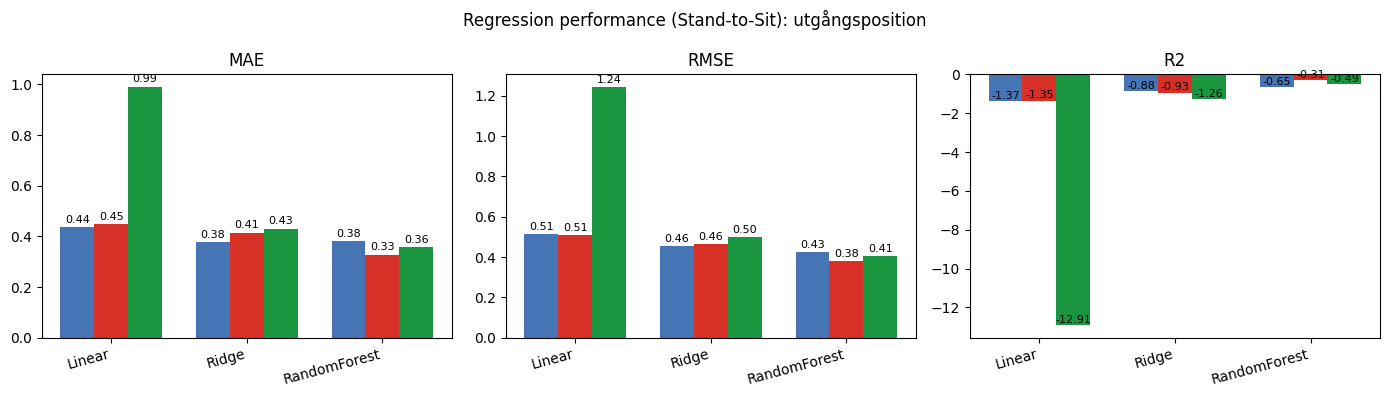

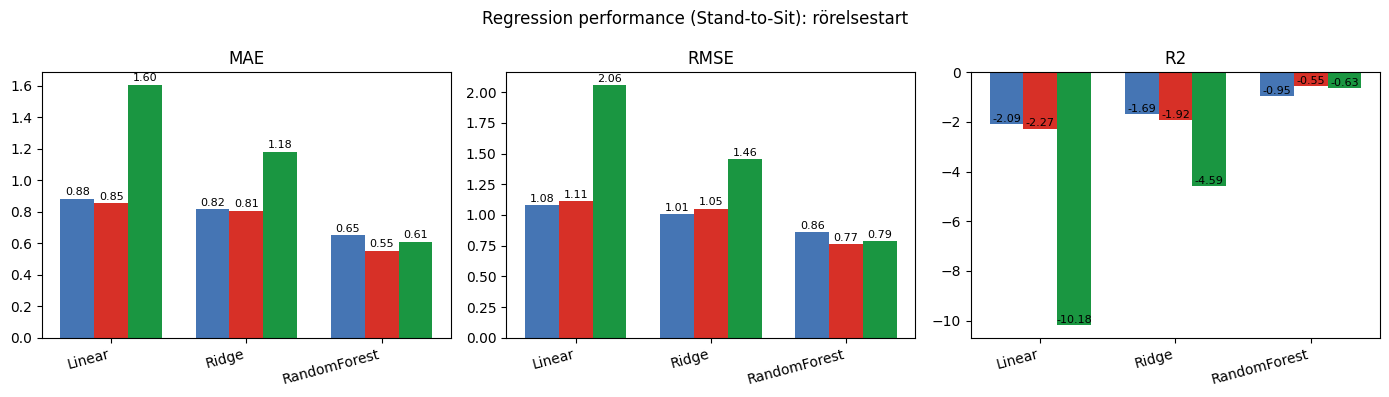

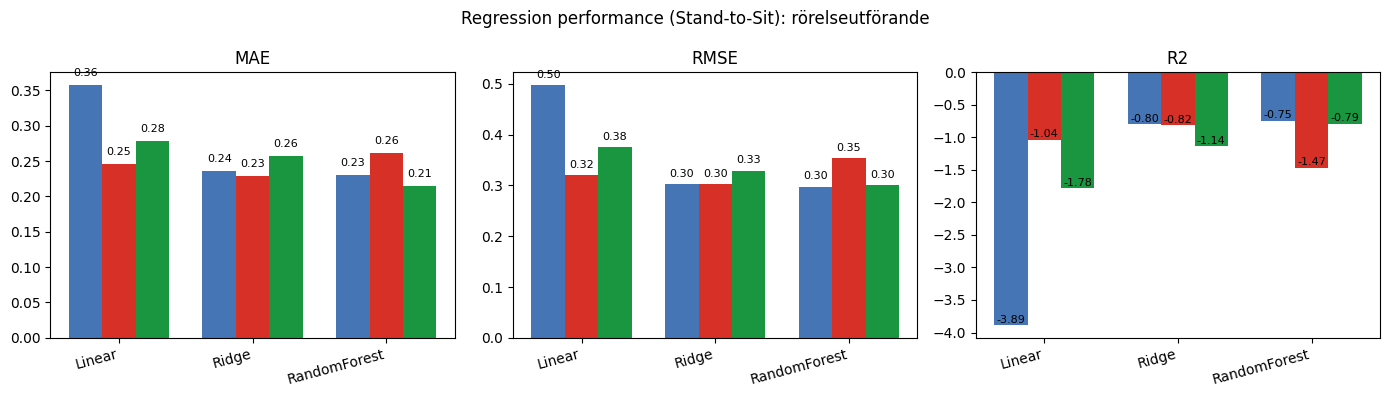

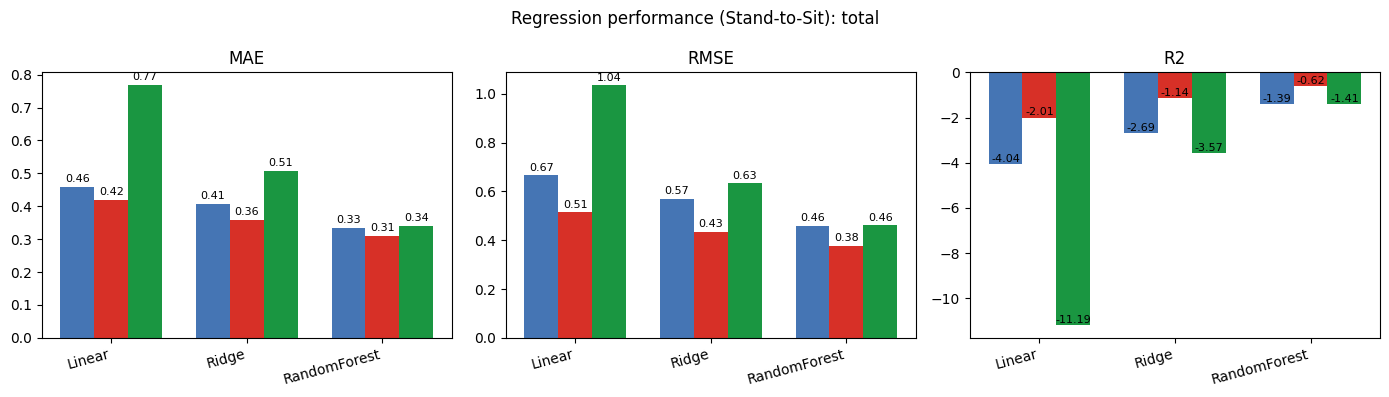

In [18]:
PHASE_ORDER_DOWN = list(phase_dfs_down.keys())
COLORS_FS = {'pose': '#4575b4', 'molab': '#d73027', 'combined': '#1a9641'}

for phase in PHASE_ORDER_DOWN:
    sub = eval_df_down[eval_df_down['phase'] == phase]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
        x = np.arange(len(MODEL_ORDER))
        width = 0.25
        for i, fs in enumerate(FEATURE_SETS):
            vals = [sub[(sub['model'] == m) & (sub['feature_set'] == fs)][metric].values[0]
                    for m in MODEL_ORDER]
            bars = ax.bar(x + i*width, vals, width, label=fs, color=COLORS_FS[fs])
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=8)
        ax.set_title(metric)
        ax.set_xticks(x + width)
        ax.set_xticklabels(MODEL_ORDER, rotation=15, ha='right')
        if i == 0:
            ax.legend()
    fig.suptitle(f'Regression performance (Stand-to-Sit): {phase}', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR_DOWN / f'regression_{phase}.png', dpi=150, bbox_inches='tight')
    plt.show()


In [19]:
anova_rows_d = []

for phase in PHASE_ORDER_DOWN:
    for model_name in MODEL_ORDER:
        errors = {}
        for fs in FEATURE_SETS:
            r = next(x for x in loocv_results_down
                     if x['phase'] == phase and x['model'] == model_name and x['feature_set'] == fs)
            errors[fs] = np.abs(r['y_true'] - r['y_pred'])
        f_stat, p_val = f_oneway(errors['pose'], errors['molab'], errors['combined'])
        anova_rows_d.append({
            'phase': phase, 'model': model_name,
            'F': round(f_stat, 3), 'p': round(p_val, 3),
            'significant': p_val < 0.05,
        })

anova_df_down = pd.DataFrame(anova_rows_d)
anova_df_down


,phase,model,F,p,significant
0,utgångsposition,Linear,3.866,0.033,True
1,utgångsposition,Ridge,0.119,0.888,False
2,utgångsposition,RandomForest,0.167,0.847,False
3,rörelsestart,Linear,1.902,0.169,False
4,rörelsestart,Ridge,0.810,0.455,False
5,rörelsestart,RandomForest,0.076,0.927,False
6,rörelseutförande,Linear,0.394,0.678,False
7,rörelseutförande,Ridge,0.050,0.952,False
8,rörelseutförande,RandomForest,0.111,0.896,False
9,total,Linear,1.229,0.308,False


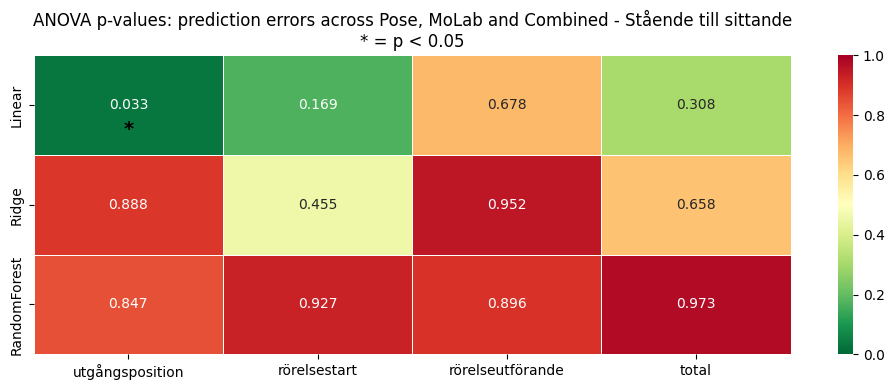

In [20]:
pivot_p_d = anova_df_down.pivot(index='model', columns='phase', values='p')
pivot_p_d = pivot_p_d.loc[MODEL_ORDER, PHASE_ORDER_DOWN]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_p_d, annot=True, fmt='.3f', cmap='RdYlGn_r', vmin=0, vmax=1,
            ax=ax, linewidths=0.5, annot_kws={'size': 10})
for i, model in enumerate(pivot_p_d.index):
    for j, phase in enumerate(pivot_p_d.columns):
        if pivot_p_d.loc[model, phase] < 0.05:
            ax.text(j + 0.5, i + 0.75, '*', ha='center', va='center', fontsize=14, fontweight='bold')

ax.set_title('ANOVA p-values: prediction errors across Pose, MoLab and Combined - St\u00e5ende till sittande\n* = p < 0.05', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUT_DIR_DOWN / 'anova_pvalues.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
for phase in PHASE_ORDER_DOWN:
    for fs in FEATURE_SETS:
        r = next(x for x in loocv_results_down
                 if x['phase'] == phase and x['model'] == 'RandomForest' and x['feature_set'] == fs)
        imp_df = pd.DataFrame({'feature': r['feature_names'], 'importance': r['mean_importances']})
        imp_df = imp_df.sort_values('importance', ascending=False)
        print(f"\n{phase} | {fs}")
        print(imp_df.round(4).to_string(index=False))



utgångsposition | pose
                         feature  importance
pose_fas1_peak_pelvis_velocity_y      0.5231
               pose_stance_width      0.2419
        pose_stance_to_hip_ratio      0.2350

utgångsposition | molab
                   feature  importance
molab_fas1_peak_thigh_gyro      0.5017
 molab_fas1_pelvis_lateral      0.3422
        molab_fas2_ROM_hip      0.1562

utgångsposition | combined
                         feature  importance
      molab_fas1_peak_thigh_gyro      0.3051
       molab_fas1_pelvis_lateral      0.2485
pose_fas1_peak_pelvis_velocity_y      0.1565
              molab_fas2_ROM_hip      0.1166
        pose_stance_to_hip_ratio      0.0939
               pose_stance_width      0.0794

rörelsestart | pose
                         feature  importance
             pose_fas2_knee_asym      0.4335
      pose_fas2_rms_pelvis_acc_x      0.3131
pose_peak_trunk_angular_velocity      0.2534

rörelsestart | molab
                   feature  importance
molab_mean

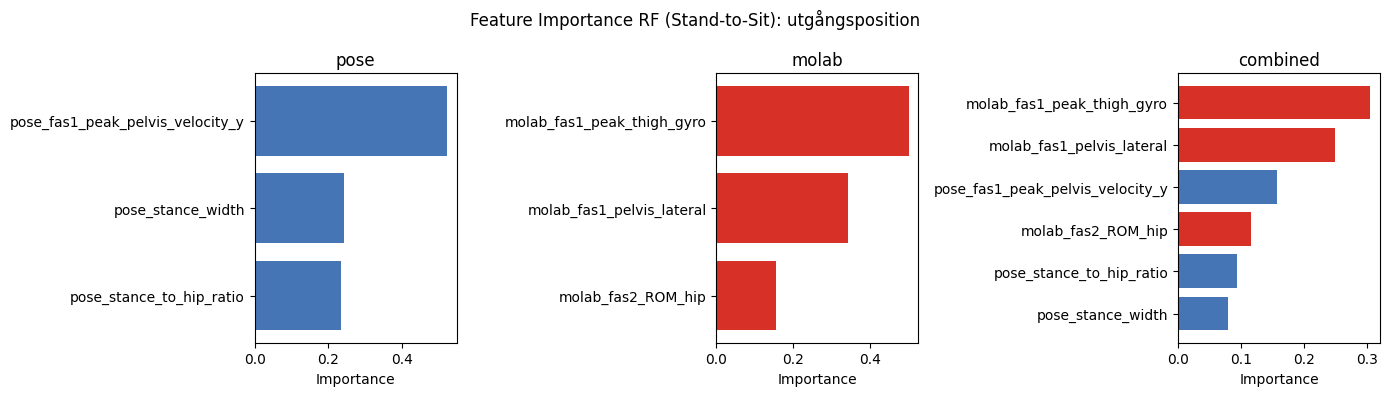

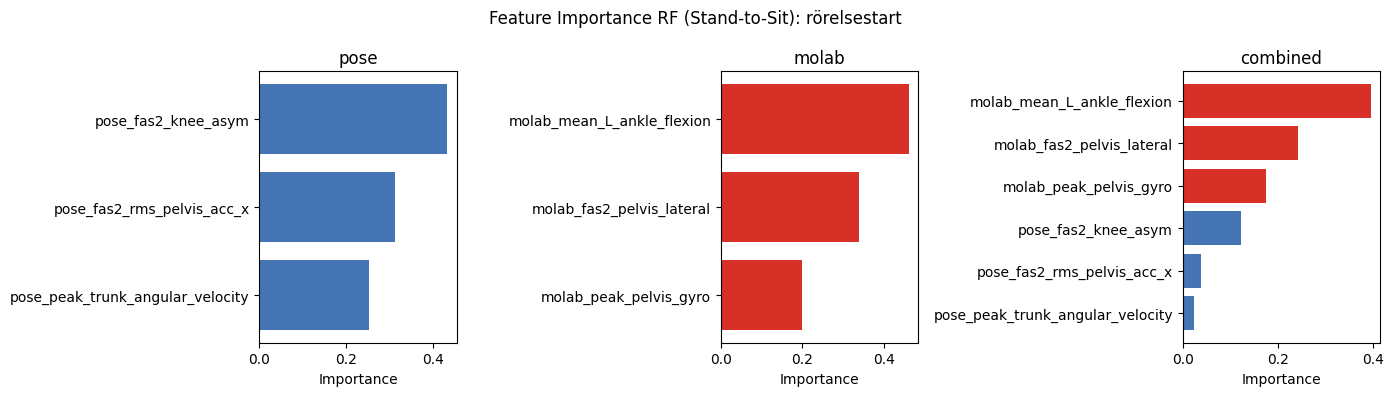

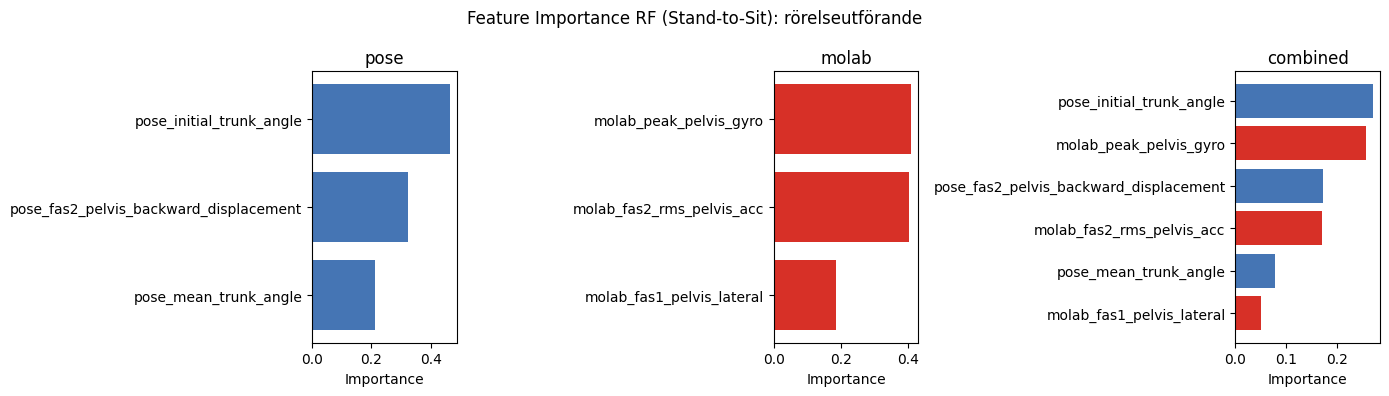

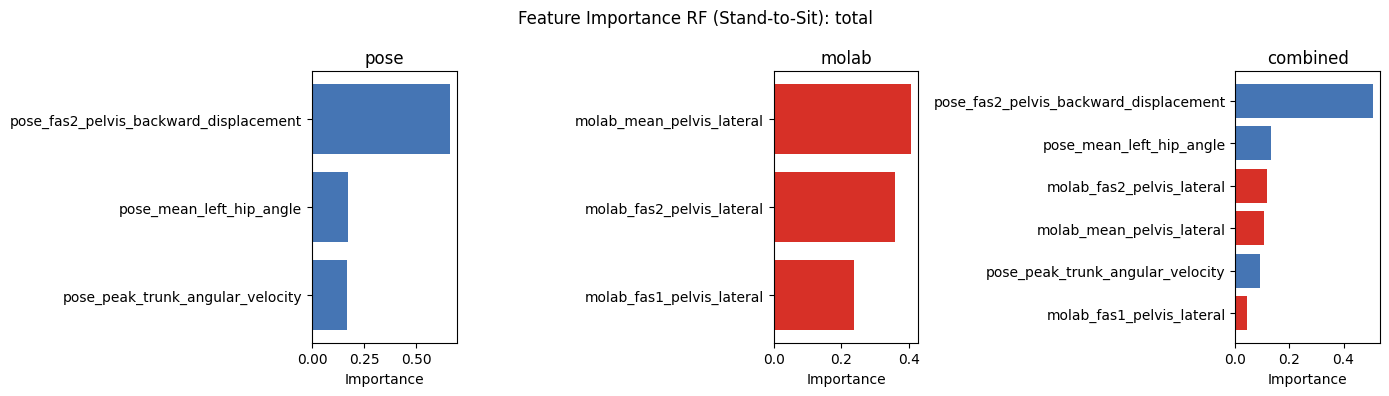

In [22]:
for phase in PHASE_ORDER_DOWN:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, fs in zip(axes, FEATURE_SETS):
        r = next(x for x in loocv_results_down
                 if x['phase'] == phase and x['model'] == 'RandomForest' and x['feature_set'] == fs)
        imp_df = pd.DataFrame({'feature': r['feature_names'], 'importance': r['mean_importances']})
        imp_df = imp_df.sort_values('importance')
        colors = ['#d73027' if 'molab_' in f else '#4575b4' for f in imp_df['feature']]
        ax.barh(imp_df['feature'], imp_df['importance'], color=colors)
        ax.set_title(fs)
        ax.set_xlabel('Importance')
    fig.suptitle(f'Feature Importance RF (Stand-to-Sit): {phase}', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR_DOWN / f'feature_importance_{phase}.png', dpi=150, bbox_inches='tight')
    plt.show()


In [23]:
videos_down = phase_dfs_down['utgångsposition']['y']['video'].tolist()

for phase in PHASE_ORDER_DOWN:
    pose_r  = next(r for r in loocv_results_down if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'pose')
    molab_r = next(r for r in loocv_results_down if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'molab')

    df = pd.DataFrame({
        'video':       videos_down,
        'pose_error':  np.abs(pose_r['y_true']  - pose_r['y_pred']),
        'molab_error': np.abs(molab_r['y_true'] - molab_r['y_pred']),
    })
    df['better'] = df.apply(lambda row: 'Pose' if row['pose_error'] < row['molab_error'] else 'MoLab', axis=1)

    print(f"\n{'='*60}\nPhase: {phase}\n{'='*60}")
    print(df.round(4).to_string(index=False))



Phase: utgångsposition
video  pose_error  molab_error better
  028      0.3813       0.3082  MoLab
  045      0.5003       0.6759   Pose
  059      0.0543       0.1682   Pose
  074      0.5551       0.4388  MoLab
  091      0.2342       0.1180  MoLab
  030      0.6860       0.6106  MoLab
  047      0.2809       0.1563  MoLab
  061      0.1314       0.0899  MoLab
  076      0.5696       0.3713  MoLab
  093      0.4180       0.3467  MoLab

Phase: rörelsestart
video  pose_error  molab_error better
  028      0.5667       0.6267   Pose
  045      0.0456       0.2133   Pose
  059      0.6533       0.6200  MoLab
  074      0.3600       0.1067  MoLab
  091      0.1178       0.1800   Pose
  030      0.6150       0.1667  MoLab
  047      0.2000       0.7733   Pose
  061      0.5833       0.2333  MoLab
  076      1.9244       1.9800   Pose
  093      1.4267       0.6267  MoLab

Phase: rörelseutförande
video  pose_error  molab_error better
  028      0.0706       0.0695  MoLab
  045      0.3585 

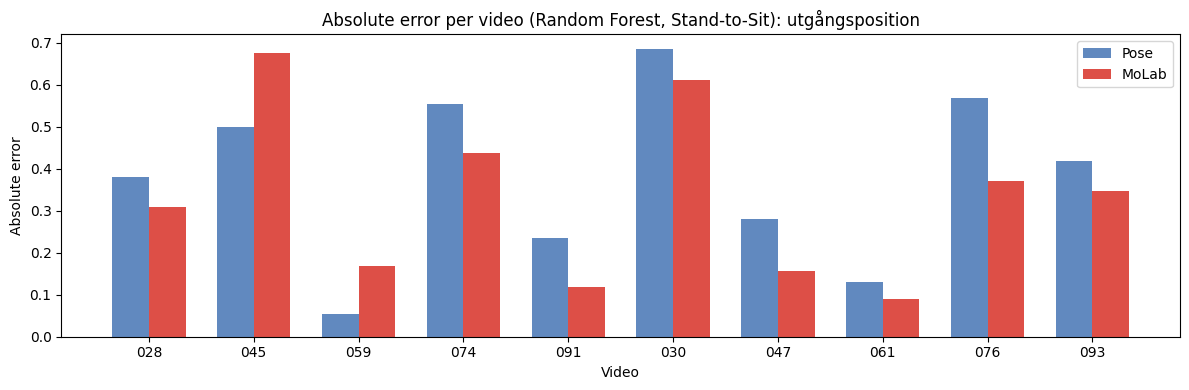

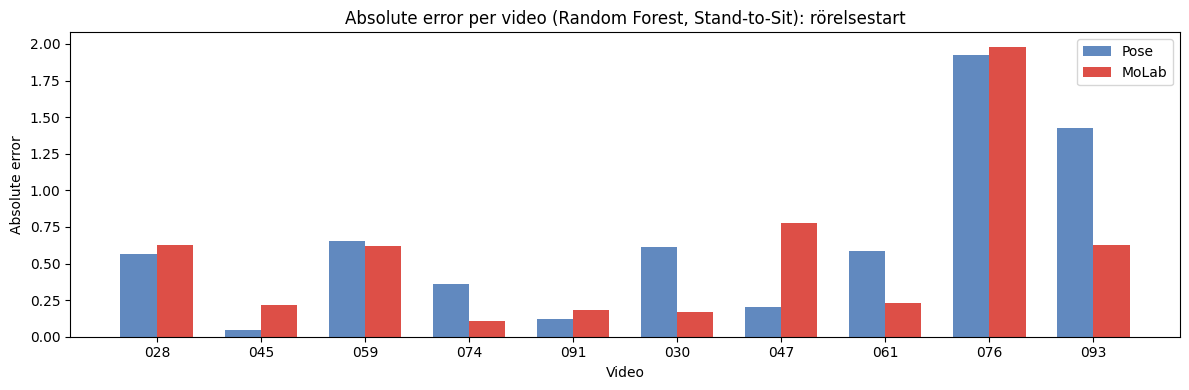

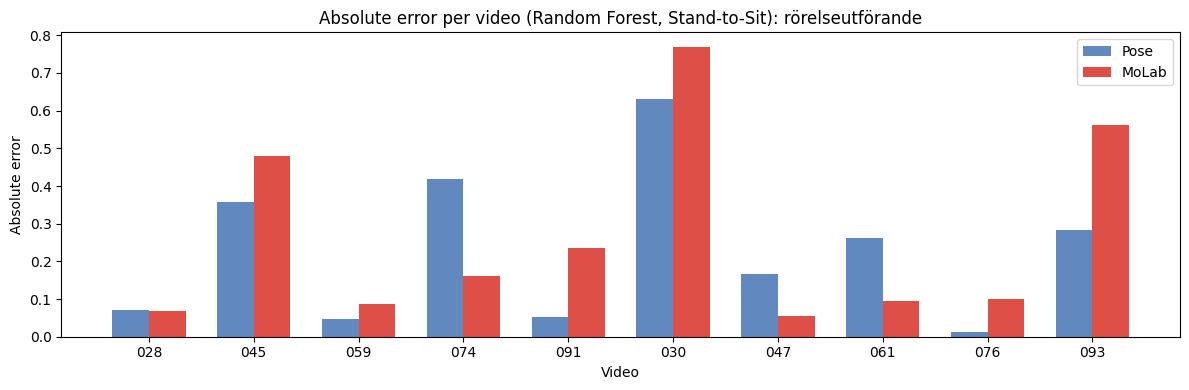

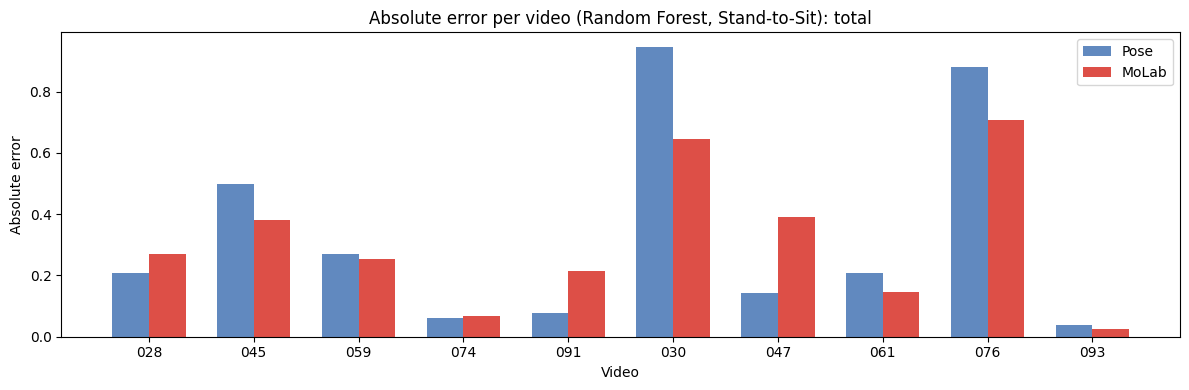

In [24]:
x_d = np.arange(len(videos_down))
width = 0.35

for phase in PHASE_ORDER_DOWN:
    pose_r  = next(r for r in loocv_results_down if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'pose')
    molab_r = next(r for r in loocv_results_down if r['phase'] == phase and r['model'] == 'RandomForest' and r['feature_set'] == 'molab')

    pose_errors  = np.abs(pose_r['y_true']  - pose_r['y_pred'])
    molab_errors = np.abs(molab_r['y_true'] - molab_r['y_pred'])

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(x_d - width/2, pose_errors,  width, label='Pose',  color='#4575b4', alpha=0.85)
    ax.bar(x_d + width/2, molab_errors, width, label='MoLab', color='#d73027', alpha=0.85)
    ax.set_title(f'Absolute error per video (Random Forest, Stand-to-Sit): {phase}')
    ax.set_xticks(x_d)
    ax.set_xticklabels(videos_down)
    ax.set_xlabel('Video')
    ax.set_ylabel('Absolute error')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR_DOWN / f'error_analysis_{phase}.png', dpi=150, bbox_inches='tight')
    plt.show()
